# Лабораторная работа: Деревья решений и случайный лес

*ML-3.2 Способен комплексно применять методы байесовской классификации и ансамблевые методы МО (бэггинг, бустинг, стэкинг моделей), а также производные от них (случайный лес, градиентный бустинг на деревьях), выдерживая баланс между вероятностной интерпретацией данных и комплексированием алгоритмов*

Сделайте копию этого файла (Файл - Сохранить копию на диске), переименуйте её, добавив в название вашу фамилию. Например, Иванова_Деревья_Лес.ipynb

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import load_digits, load_wine, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Библиотеки загружены.")

Библиотеки загружены.


# Часть 1. Дерево решений (одиночное дерево)

Дерево решений — один из самых интерпретируемых алгоритмов машинного обучения. Оно последовательно разбивает данные по значениям признаков, строя дерево, где каждый лист содержит объекты одного класса.

**Ключевые понятия:**
- **Корень дерева** — первый узел, с которого начинается разбиение
- **Внутренний узел** — проверка условия по одному из признаков
- **Лист** — конечный узел, содержащий предсказание
- **Глубина дерева** — максимальная длина пути от корня до листа
- **Критерий ветвления** — правило, по которому выбирается лучшее разбиение

**Критерии ветвления:**
- **Gini (примесь Джини)** — $Gini = 1 - \sum_{i=1}^{C} p_i^2$. Чем меньше значение, тем "чище" узел.
- **Entropy (энтропия Шеннона)** — $Entropy = -\sum_{i=1}^{C} p_i \log_2(p_i)$. Также измеряет неопределенность.

**Почему дерево решений — это "белый ящик"?**
- Легко визуализировать и объяснить
- Можно проследить путь решения для любого объекта
- Веса признаков интерпретируемы

**Основные гиперпараметры дерева:**
- `max_depth` — максимальная глубина (ограничивает переобучение)
- `min_samples_split` — минимальное число объектов для разбиения
- `min_samples_leaf` — минимальное число объектов в листе
- `criterion` — критерий ветвления ("gini" или "entropy")
- `max_features` — число признаков для поиска лучшего разбиения

Размерность данных: (1797, 64)
Количество классов: 10


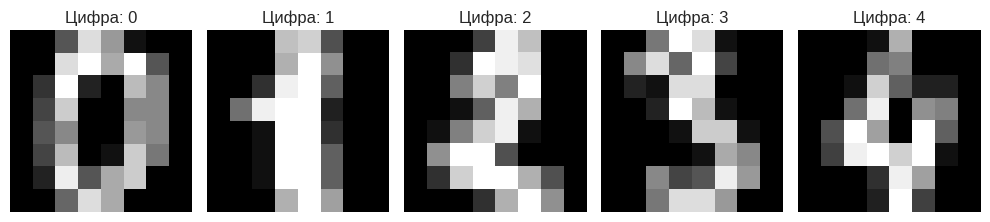

In [3]:
# Загружаем датасет Digits
digits = load_digits()
X = digits.data
y = digits.target

print(f"Размерность данных: {X.shape}")
print(f"Количество классов: {len(np.unique(y))}")

# Визуализация нескольких цифр
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    axes[i].imshow(digits.images[i], cmap='gray')
    axes[i].set_title(f"Цифра: {y[i]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

**Вопросы для размышления (ответьте письменно):**

1. Деревья решений не требуют стандартизации данных. Почему?
2. Какие типы данных (числовые, категориальные) может обрабатывать дерево решений?
3. В чем основное преимущество дерева решений перед логистической регрессией?

In [4]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

Размер обучающей выборки: 1257
Размер тестовой выборки: 540


## 1.1. Базовое обучение и визуализация дерева

Обучим дерево решений с параметрами по умолчанию и визуализируем его структуру.

In [5]:
# Создаем и обучаем дерево
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

# Предсказание
y_pred_tree = tree_clf.predict(X_test)

# Оценка качества
print("=== Дерево решений (параметры по умолчанию) ===")
print(f"Точность (Accuracy): {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"F1-score (macro): {f1_score(y_test, y_pred_tree, average='macro'):.4f}")
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred_tree))

=== Дерево решений (параметры по умолчанию) ===
Точность (Accuracy): 0.8426
F1-score (macro): 0.8409

Отчет по классификации:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        53
           1       0.74      0.78      0.76        50
           2       0.83      0.74      0.79        47
           3       0.78      0.85      0.81        54
           4       0.81      0.85      0.83        60
           5       0.92      0.86      0.89        66
           6       0.93      0.94      0.93        53
           7       0.85      0.84      0.84        55
           8       0.89      0.77      0.82        43
           9       0.78      0.85      0.81        59

    accuracy                           0.84       540
   macro avg       0.85      0.84      0.84       540
weighted avg       0.85      0.84      0.84       540



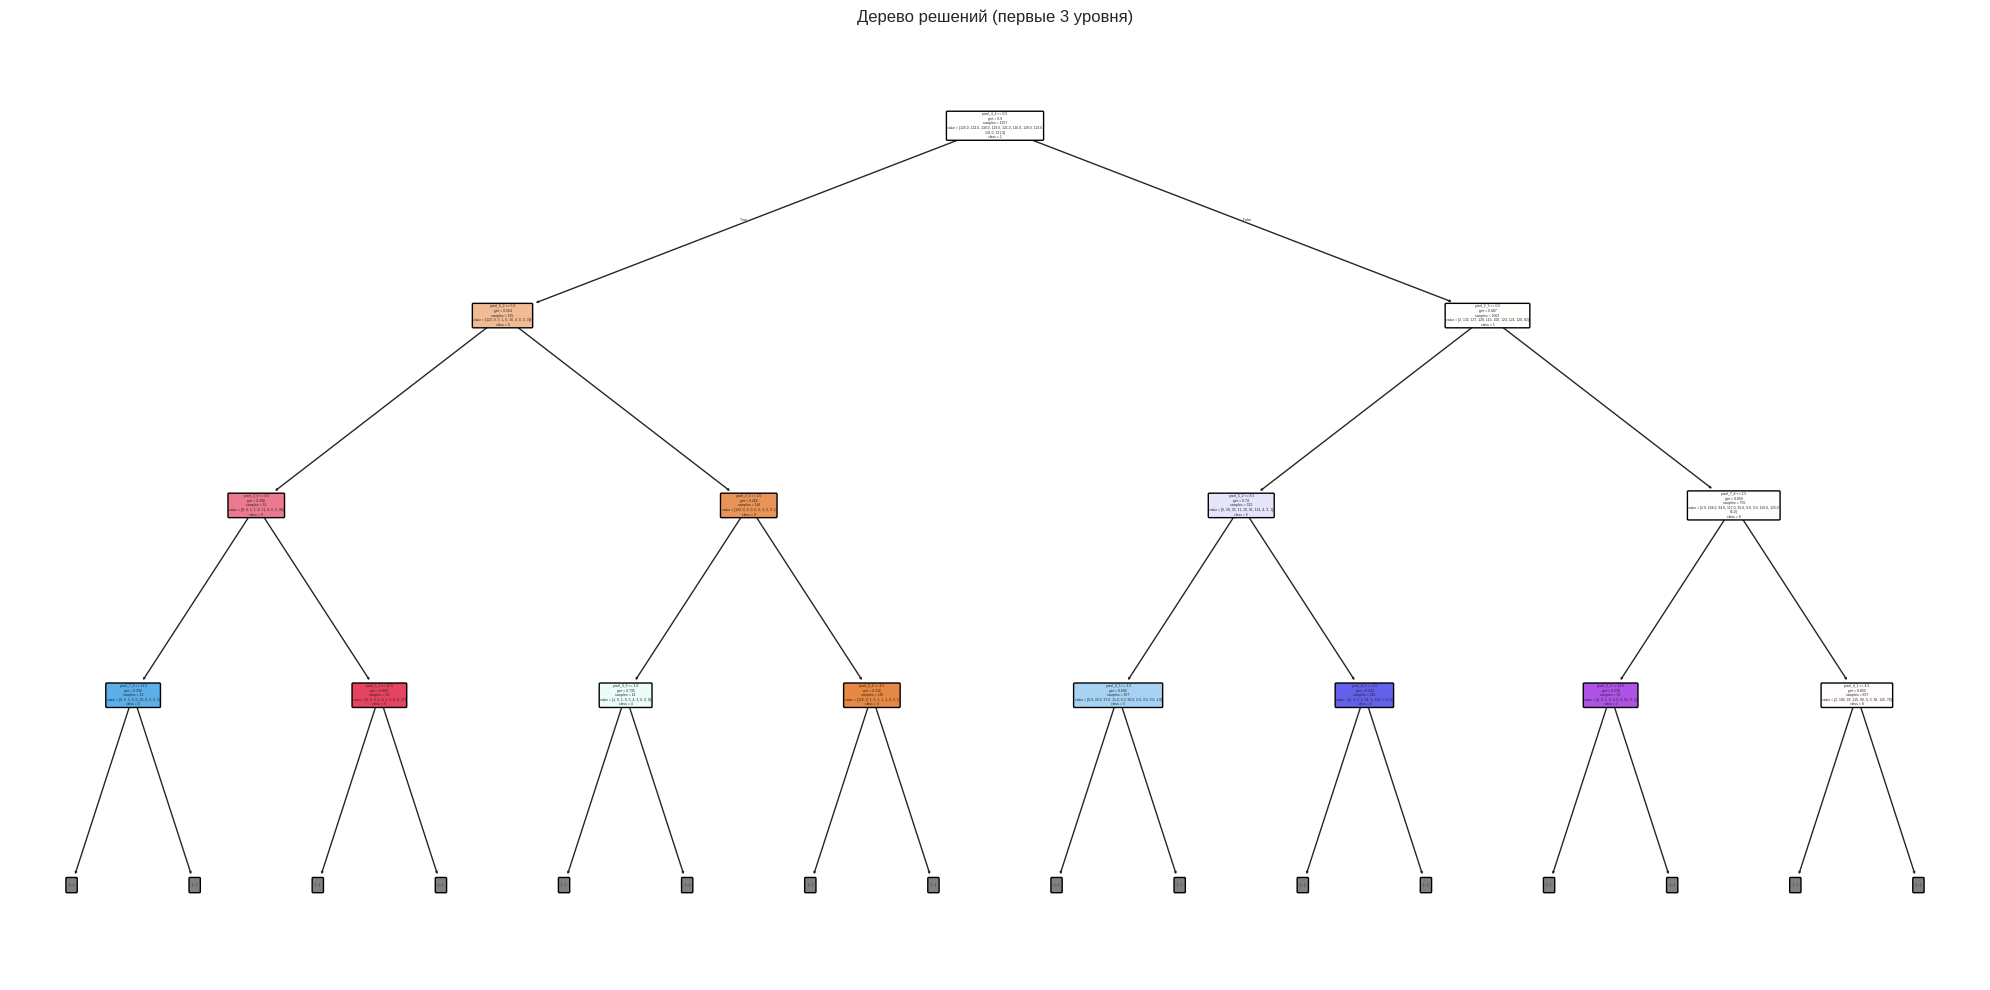

Глубина дерева: 14
Количество листьев: 135


In [6]:
# Визуализация дерева (первые 3 уровня)
plt.figure(figsize=(20, 10))
plot_tree(tree_clf, max_depth=3, feature_names=digits.feature_names,
          class_names=[str(i) for i in range(10)], filled=True, rounded=True)
plt.title('Дерево решений (первые 3 уровня)')
plt.tight_layout()
plt.show()

print(f"Глубина дерева: {tree_clf.get_depth()}")
print(f"Количество листьев: {tree_clf.get_n_leaves()}")

## 1.2. Сравнение критериев ветвления: Gini vs Entropy

**Вопросы для размышления:**
- Какой критерий дает лучшее качество на этих данных?
- Какой критерий быстрее вычисляется?
- В каких случаях энтропия может дать преимущество перед Джини?

In [7]:
# Сравнение критериев
criteria = ['gini', 'entropy']
results = []

for criterion in criteria:
    clf = DecisionTreeClassifier(criterion=criterion, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'criterion': criterion, 'accuracy': acc, 'depth': clf.get_depth(), 'leaves': clf.get_n_leaves()})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

criterion  accuracy  depth  leaves
     gini  0.842593     14     135
  entropy  0.883333     10     130


## 1.3. Влияние глубины дерева (переобучение vs недообучение)

**Практика.**

Обучите деревья с разной максимальной глубиной (от 1 до 30). Постройте график зависимости качества на обучающей и тестовой выборках.

**Вопросы для размышления:**
- При какой глубине начинает проявляться переобучение?
- Почему на обучающей выборке точность может достигать 1.0?
- Какая глубина является оптимальной для этого датасета?

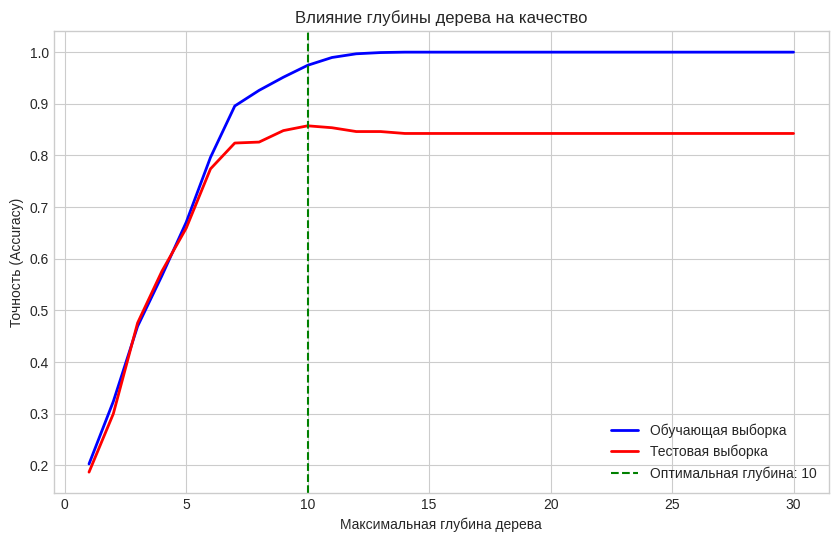

Оптимальная глубина: 10
Точность на тесте: 0.8574
Разрыв train-test: 0.1426


In [8]:
# Разместите здесь ваш код

# Анализ влияния глубины
depths = range(1, 31)
train_scores = []
test_scores = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'b-', label='Обучающая выборка', linewidth=2)
plt.plot(depths, test_scores, 'r-', label='Тестовая выборка', linewidth=2)
plt.axvline(x=depths[np.argmax(test_scores)], color='green', linestyle='--',
           label=f'Оптимальная глубина: {depths[np.argmax(test_scores)]}')
plt.xlabel('Максимальная глубина дерева')
plt.ylabel('Точность (Accuracy)')
plt.title('Влияние глубины дерева на качество')
plt.legend()
plt.grid(True)
plt.show()

print(f"Оптимальная глубина: {depths[np.argmax(test_scores)]}")
print(f"Точность на тесте: {max(test_scores):.4f}")
print(f"Разрыв train-test: {max(train_scores) - max(test_scores):.4f}")

## 1.4. Влияние минимального числа объектов в листе

**Практика.**

Обучите деревья с разным `min_samples_leaf` (от 1 до 50). Проанализируйте влияние на качество и структуру дерева.

**Вопросы для размышления:**
- Как увеличение `min_samples_leaf` влияет на глубину дерева?
- Как это влияет на переобучение?
- Какое значение оптимально для данного датасета?

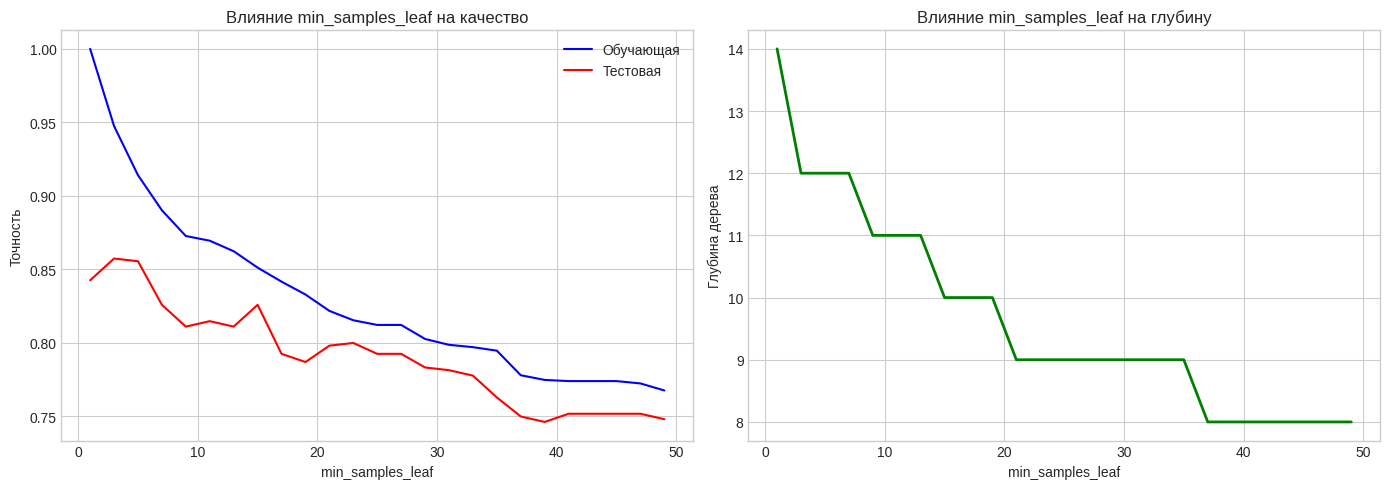

In [9]:
# Разместите здесь ваш код

# Анализ влияния min_samples_leaf
min_samples = range(1, 51, 2)
train_scores_leaf = []
test_scores_leaf = []
depths_leaf = []

for min_s in min_samples:
    clf = DecisionTreeClassifier(min_samples_leaf=min_s, random_state=42)
    clf.fit(X_train, y_train)
    train_scores_leaf.append(clf.score(X_train, y_train))
    test_scores_leaf.append(clf.score(X_test, y_test))
    depths_leaf.append(clf.get_depth())

# График качества
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(min_samples, train_scores_leaf, 'b-', label='Обучающая')
axes[0].plot(min_samples, test_scores_leaf, 'r-', label='Тестовая')
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('Точность')
axes[0].set_title('Влияние min_samples_leaf на качество')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(min_samples, depths_leaf, 'g-', linewidth=2)
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('Глубина дерева')
axes[1].set_title('Влияние min_samples_leaf на глубину')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 1.5. Интерпретация: важность признаков

Дерево решений позволяет оценить важность каждого признака. Чем выше значение, тем больше признак влияет на предсказание.

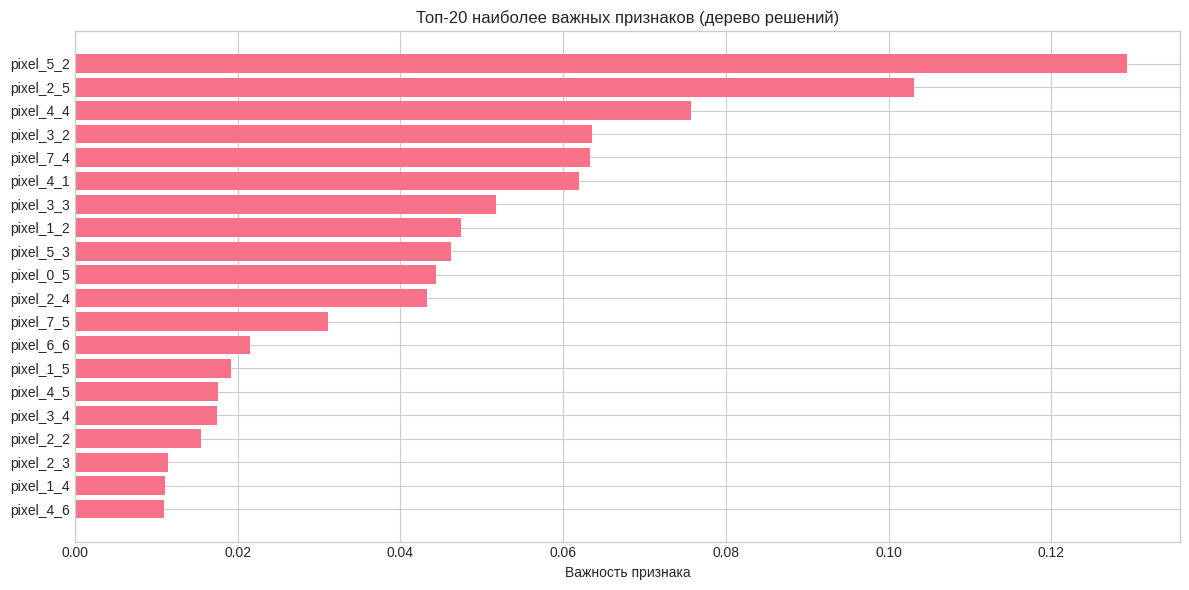

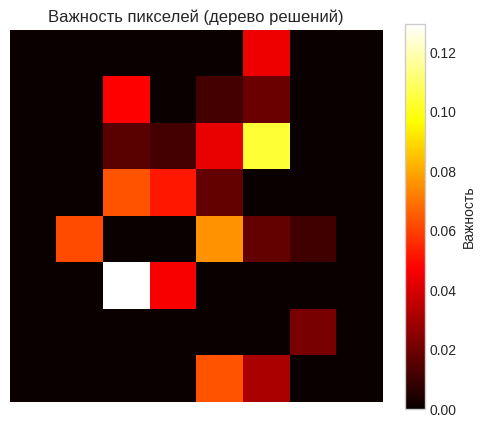

In [10]:
# Важность признаков для дерева
importances_tree = tree_clf.feature_importances_

# Визуализация важности признаков
plt.figure(figsize=(12, 6))
indices = np.argsort(importances_tree)[-20:]  # Топ-20
plt.barh(range(20), importances_tree[indices])
plt.yticks(range(20), [digits.feature_names[i] for i in indices])
plt.xlabel('Важность признака')
plt.title('Топ-20 наиболее важных признаков (дерево решений)')
plt.tight_layout()
plt.show()

# Визуализация весов как изображения
importance_image = np.zeros(64)
importance_image[indices] = importances_tree[indices]
importance_image = importance_image.reshape(8, 8)

plt.figure(figsize=(6, 5))
plt.imshow(importance_image, cmap='hot', interpolation='nearest')
plt.colorbar(label='Важность')
plt.title('Важность пикселей (дерево решений)')
plt.axis('off')
plt.show()

# Часть 2. Бэггинг и случайный лес

Одиночное дерево решений часто переобучается. Ансамблевые методы решают эту проблему, комбинируя множество деревьев.

## 2.1. Бэггинг (Bagging)

**Bagging (Bootstrap Aggregating)** — метод, который:
1. Создает множество подвыборок из исходных данных (с возвращением)
2. Обучает отдельное дерево на каждой подвыборке
3. Для классификации использует голосование

**Ключевой параметр:** `n_estimators` — число деревьев в ансамбле.

**Вопрос для размышления:** Почему бэггинг эффективно снижает дисперсию, но не влияет на смещение?

In [ ]:
from sklearn.ensemble import BaggingClassifier

# Бэггинг на основе дерева решений
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)

y_pred_bagging = bagging.predict(X_test)

print("=== Бэггинг (50 деревьев) ===")
print(f"Точность (Accuracy): {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"F1-score (macro): {f1_score(y_test, y_pred_bagging, average='macro'):.4f}")

## 2.2. Случайный лес (Random Forest)

Случайный лес — это улучшенная версия бэггинга с **дополнительным источником случайности**: при построении каждого узла дерева рассматривается не все признаки, а их случайное подмножество (`max_features`).

**Преимущества случайного леса:**
- Еще более устойчив к переобучению, чем бэггинг
- Хорошо работает с большим числом признаков
- Позволяет оценить важность признаков
- Дает OOB-оценку (Out-of-Bag) для контроля качества без кросс-валидации

**Ключевые параметры:**
- `n_estimators` — число деревьев
- `max_depth` — максимальная глубина
- `max_features` — число признаков для разбиения
- `min_samples_split` — минимальное число объектов для разбиения
- `oob_score` — использовать ли OOB-оценку

In [ ]:
# Случайный лес с параметрами по умолчанию
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print("=== Случайный лес (100 деревьев) ===")
print(f"Точность (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-score (macro): {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"OOB Score: {rf_clf.oob_score_:.4f}")

## 2.3. Сравнение важности признаков: дерево vs лес

**Практика.**

Сравните важность признаков, полученную из одиночного дерева и случайного леса.

**Вопросы для размышления:**
- Почему важности признаков в случайном лесе часто более "стабильны"?
- Какие пиксели оказались наиболее важными для распознавания цифр?
- Как это соотносится с визуальным представлением цифр?

In [ ]:
# Разместите здесь ваш код

# Сравнение важности признаков
importances_rf = rf_clf.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Дерево
axes[0].barh(range(20), importances_tree[indices])
axes[0].set_title('Дерево решений (топ-20)')
axes[0].set_xlabel('Важность')

# Случайный лес
indices_rf = np.argsort(importances_rf)[-20:]
axes[1].barh(range(20), importances_rf[indices_rf])
axes[1].set_title('Случайный лес (топ-20)')
axes[1].set_xlabel('Важность')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([digits.feature_names[i] for i in indices_rf])

plt.tight_layout()
plt.show()

# Визуализация важности как изображений
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

imp_tree_img = importances_tree.reshape(8, 8)
imp_rf_img = importances_rf.reshape(8, 8)

axes[0].imshow(imp_tree_img, cmap='hot', interpolation='nearest')
axes[0].set_title('Важность пикселей (дерево)')
axes[0].axis('off')

axes[1].imshow(imp_rf_img, cmap='hot', interpolation='nearest')
axes[1].set_title('Важность пикселей (случайный лес)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Часть 3. Подбор гиперпараметров случайного леса

Правильный подбор гиперпараметров критически влияет на качество модели. Рассмотрим ключевые параметры.

## 3.1. Влияние числа деревьев (n_estimators)

**Практика.**

Обучите случайные леса с разным числом деревьев (от 1 до 200). Отслеживайте качество на обучающей и тестовой выборках, а также OOB-оценку.

**Вопрос для размышления:** С какого момента увеличение числа деревьев перестает давать прирост качества?

In [ ]:
# Разместите здесь ваш код

# Анализ влияния n_estimators
n_estimators_range = [1, 5, 10, 20, 50, 100, 150, 200]
train_scores_rf = []
test_scores_rf = []
oob_scores = []
times = []

for n in n_estimators_range:
    start = time.time()
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1, oob_score=True)
    rf.fit(X_train, y_train)
    times.append(time.time() - start)

    train_scores_rf.append(rf.score(X_train, y_train))
    test_scores_rf.append(rf.score(X_test, y_test))
    oob_scores.append(rf.oob_score_)

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_estimators_range, train_scores_rf, 'b-', label='Обучающая')
axes[0].plot(n_estimators_range, test_scores_rf, 'r-', label='Тестовая')
axes[0].plot(n_estimators_range, oob_scores, 'g-', label='OOB')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Точность')
axes[0].set_title('Влияние числа деревьев на качество')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(n_estimators_range, times, 'purple', linewidth=2)
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Время обучения (сек)')
axes[1].set_title('Влияние числа деревьев на время обучения')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3.2. GridSearchCV для случайного леса

**Практика.**

Используйте GridSearchCV для подбора оптимальных параметров случайного леса.

**Рекомендуемые параметры для перебора:**
- `n_estimators`: [50, 100, 150]
- `max_depth`: [10, 20, None]
- `max_features`: ['sqrt', 'log2', None]
- `min_samples_split`: [2, 5, 10]

**Вопросы для размышления:**
- Какие параметры оказались оптимальными?
- Как изменилось качество по сравнению с параметрами по умолчанию?
- Сколько времени занял подбор параметров?

In [ ]:
# Разместите здесь ваш код

# GridSearchCV для случайного леса
from sklearn.model_selection import GridSearchCV

# Упрощенная сетка для ускорения (в реальной задаче можно расширить)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True)
grid_rf = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

start = time.time()
grid_rf.fit(X_train, y_train)
grid_time = time.time() - start

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_rf.best_score_:.4f}")
print(f"Время подбора: {grid_time:.2f} сек")

# Оценка на тесте
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print(f"Точность на тесте: {accuracy_score(y_test, y_pred_best_rf):.4f}")

# Часть 4. Сравнение с линейными моделями

**Практика.**

Сравните качество случайного леса с логистической регрессией (базовый уровень).

**Вопросы для размышления:**
- Какая модель показала лучшее качество? Почему?
- Какая модель быстрее обучается?
- Какая модель проще для интерпретации?
- В каких задачах вы бы предпочли логистическую регрессию, а в каких — случайный лес?

In [ ]:
# Разместите здесь ваш код

# Сравнение моделей
# Логистическая регрессия
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Сравнение метрик
models = {
    'Логистическая регрессия': (y_pred_lr, lr),
    'Дерево решений': (y_pred_tree, tree_clf),
    'Случайный лес (default)': (y_pred_rf, rf_clf),
    'Случайный лес (оптимальный)': (y_pred_best_rf, best_rf)
}

comparison = []
for name, (y_pred, model) in models.items():
    start = time.time()
    _ = model.predict(X_test)
    pred_time = time.time() - start

    comparison.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'Время предсказания (ms)': pred_time * 1000,
        'Интерпретируемость': 'Высокая' if name in ['Логистическая регрессия', 'Дерево решений'] else 'Средняя'
    })

df_comparison = pd.DataFrame(comparison)
print(df_comparison.to_string(index=False))

# Часть 5. Работа с категориальными признаками и пропусками

В реальных данных часто встречаются категориальные признаки и пропуски. Рассмотрим, как работать с ними.

## 5.1. Работа с категориальными признаками

Для работы с категориальными признаками можно использовать:
- `LabelEncoder` — преобразование в числа (для порядковых категорий)
- `OneHotEncoder` — создание бинарных признаков (для номинальных категорий)
- `pd.get_dummies` — аналогично OneHotEncoder в pandas

In [ ]:
# Пример работы с категориальными признаками
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Создаем пример с категориальными данными
data_cat = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'red', 'blue'],
    'size': ['S', 'M', 'L', 'M', 'S'],
    'price': [100, 150, 200, 120, 130]
})

print("Исходные данные:")
print(data_cat)

# LabelEncoder (для порядковых категорий)
le = LabelEncoder()
data_cat['size_encoded'] = le.fit_transform(data_cat['size'])

# OneHotEncoder (для номинальных категорий)
ohe = OneHotEncoder(sparse_output=False, drop='first')
color_encoded = ohe.fit_transform(data_cat[['color']])
color_df = pd.DataFrame(color_encoded, columns=ohe.get_feature_names_out(['color']))

data_cat_encoded = pd.concat([data_cat, color_df], axis=1)
print("\nПосле кодирования:")
print(data_cat_encoded)

## 5.2. Работа с пропущенными данными

Для работы с пропусками можно использовать:
- `SimpleImputer` — заполнение средним, медианой, модой или константой
- `KNNImputer` — заполнение на основе ближайших соседей
- `pandas.fillna()` — ручное заполнение

In [ ]:
from sklearn.impute import SimpleImputer

# Создаем данные с пропусками
data_missing = pd.DataFrame({
    'feature_1': [1, 2, np.nan, 4, 5],
    'feature_2': [10, np.nan, 30, 40, 50],
    'target': [0, 1, 0, 1, 0]
})

print("Исходные данные с пропусками:")
print(data_missing)

# Заполнение средним
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(data_missing[['feature_1', 'feature_2']])

data_filled = pd.DataFrame(X_imputed, columns=['feature_1', 'feature_2'])
data_filled['target'] = data_missing['target']

print("\nПосле заполнения пропусков:")
print(data_filled)

# Часть 6. Дополнительное задание (по вариантам)

Выберите вариант в соответствии с номером вашей зачетной книжки (последняя цифра).

**Общие требования:**
1. Загрузите данные
2. Выполните предобработку (стандартизация, кодирование категорий, заполнение пропусков)
3. Обучите дерево решений и случайный лес
4. Выполните подбор гиперпараметров (GridSearchCV)
5. Сравните модели по метрикам
6. Сделайте выводы

**Вариант 1. HR-аналитика (увольнение сотрудников)**

Загрузите набор Employee Analysis (файл HREmployeeAttrition.csv).

**Целевая переменная:** `Attrition` (увольнение: Yes/No)

**Признаки для использования:** Age, BusinessTravel, DailyRate, DistanceFromHome, Education, EnvironmentSatisfaction

**Задачи:**
1. Преобразуйте категориальные признаки в числовые
2. Обучите дерево решений и случайный лес
3. Визуализируйте дерево
4. Сравните точность моделей
5. Определите наиболее важные признаки

In [ ]:
# Вариант 1
import pandas as pd

# Загрузка данных (замените путь на актуальный)
# df = pd.read_csv('HREmployeeAttrition.csv')

# Разместите здесь ваш код

**Вариант 2. Прогнозирование оттока клиентов банка**

Загрузите набор BankCustomerChurnPrediction.csv.

**Целевая переменная:** `churn` (1 — клиент ушел, 0 — остался)

**Признаки:** все, кроме customer_id и country

**Задачи:**
1. Преобразуйте категориальные признаки в числовые
2. Обучите дерево решений и случайный лес
3. Сравните точность моделей
4. Определите наиболее важные признаки

In [ ]:
# Вариант 2
# Разместите здесь ваш код

**Вариант 3. Качество красного вина**

Загрузите набор winequality-red.csv.

**Целевая переменная:** `quality` (оценка от 0 до 10)

**Задачи:**
1. Выполните предобработку
2. Обучите дерево решений и случайный лес (задача классификации)
3. Сравните точность моделей
4. Определите наиболее важные признаки

In [ ]:
# Вариант 3
# Разместите здесь ваш код

**Вариант 4. Пингвины (регрессия)**

Загрузите встроенный набор `penguins` из seaborn.

**Целевая переменная:** `body_mass_g` (масса пингвина)

**Задачи:**
1. Выполните предобработку (кодирование категорий, заполнение пропусков)
2. Обучите дерево решений и случайный лес (задача регрессии)
3. Используйте DecisionTreeRegressor и RandomForestRegressor
4. Оцените качество по MSE и R²
5. Определите наиболее важные признаки

In [ ]:
# Вариант 4
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Разместите здесь ваш код

# Итоговые вопросы для размышления

**Ответьте письменно:**

1. Какие преимущества имеет случайный лес перед одиночным деревом решений?

2. Почему случайный лес считается устойчивым к переобучению? Чем бэггинг помогает бороться с переобучением?

3. В чем разница между критериями Джини и энтропией? Какой критерий вы бы выбрали для задачи с большим числом классов?

4. Как подбор гиперпараметров (n_estimators, max_depth, max_features) влияет на качество модели?

5. В чем заключается компромисс между интерпретируемостью и качеством при выборе между деревом и лесом?

6. Когда имеет смысл использовать логистическую регрессию вместо случайного леса, и наоборот?

7. Как обрабатывать категориальные признаки и пропуски при построении деревьев решений?

8. Опишите, как вы будете выбирать между бэггингом и случайным лесом в конкретной задаче.

**Эссе (5-7 предложений):**

На основе проведенных экспериментов опишите:
1. Какой подход (одиночное дерево, бэггинг, случайный лес) показал лучшее качество и почему
2. В каких случаях вы бы использовали одиночное дерево, а в каких — случайный лес
3. Как выбор алгоритма связан с требованиями к интерпретируемости и вычислительным ограничениям

**Ваше эссе:**